# ResNet-50 Experiment 08 — Full layer4 Unfreeze with L1 + Dropout + Patient Metadata Fusion

## Objective
Introduce patient metadata (age, sex, body localisation) as an auxiliary input fused with the ResNet-50 image features. This is motivated by the ISIC 2018 SOTA result (ResNet-50 + EfficientNet-B0 + patient metadata fusion achieving AUC >0.973 and F1 93%). Iteration 07 showed that L1 alone without dropout raises AUC slightly (0.886) but reduces F2 (0.607) due to a precision drop. Here we restore dropout (0.5) to recover precision, keep L2=0, and add metadata to give the classifier patient-level context that is invisible to image features alone.

## Architecture Changes

| Component | 07. layer4 + L1, no Dropout | 08. layer4 + L1 + Dropout + Metadata |
|---|---|---|
| Unfrozen layers | `layer4` (all 3 blocks) | `layer4` (all 3 blocks) |
| Trainable params | ~15M | ~15M + metadata encoder (~600) |
| Weight decay (AdamW) | 1e-3 | 1e-3 |
| L1 lambda | 1e-3 | 1e-3 |
| L2 lambda | 0 | 0 |
| Dropout | None | **0.5** |
| Patient metadata | None | **age + sex + localization (dim=17)** |
| Model class | `get_resnet50` | **`ResNet50WithMetadata`** |
| LR — layer4 | 1e-4 | 1e-4 |
| LR — FC/head | 1e-3 | 1e-3 |
| Epochs | 30 | 30 |

## Hypothesis
Patient metadata provides orthogonal signal to image features: age and body site are known risk factors for melanoma (older patients and truncal/extremity lesions carry higher risk). By concatenating a 32-dim metadata encoding with the 2048-dim image features before the final classifier, the model can learn to up-weight borderline image predictions when metadata indicates high risk. Restoring dropout (0.5) on the fusion head should recover the precision lost in iteration 07 while the metadata encoding compensates with additional discriminative signal.

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000DatasetWithMetadata
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import ResNet50WithMetadata
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
METADATA_PATH      = str(ROOT / 'data_new/raw/HAM10000_metadata')
TEST_METADATA_PATH = str(ROOT / 'data_new/raw/ISIC2018_Task3_Test_GroundTruth.csv')

from src.data.transform import get_eval_transforms

train_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

val_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

test_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=get_eval_transforms(image_size=224),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Metadata dim: {len(train_dataset[0][1])}')

Positive weight: tensor([8.1117], device='cuda:0')
Train: 7991 | Val: 2024 | Test: 1511
Metadata dim: 17


In [3]:
METADATA_DIM = 17  # age(1) + sex(1) + localization one-hot(15)
DROPOUT      = 0.5

model = ResNet50WithMetadata(
    metadata_dim=METADATA_DIM,
    num_classes=1,
    freeze_backbone=True,
    dropout=DROPOUT,
).to(device)

# Unfreeze full layer4 (backbone[7])
for param in model.backbone[7].parameters():
    param.requires_grad = True

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW([
    {'params': model.backbone[7].parameters(), 'lr': 1e-4},
    {'params': model.meta_encoder.parameters(), 'lr': 1e-3},
    {'params': model.head.parameters(),         'lr': 1e-3},
], weight_decay=1e-3)

num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {DROPOUT}')

Trainable params: 14,967,393 / 23,510,689
L1 lambda: 0.001 | L2 lambda: 0.0 | Dropout: 0.5


In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA, use_metadata=True,
    )
    val_metrics = validate_one_epoch(
        model, val_loader, criterion, device, use_metadata=True,
    )

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/resnet50_layer4_l1_metadata_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/30]
  Train | Loss: 0.9704, Bal Acc: 0.7138, Recall: 0.7548, F2: 0.5094, AUC: 0.7943
  Val   | Loss: 0.9009, Bal Acc: 0.7441, Recall: 0.6525, F2: 0.5532, AUC: 0.8528
  -> Saved best model (val AUC: 0.8528)


Epoch [2/30]
  Train | Loss: 0.8428, Bal Acc: 0.7684, Recall: 0.8016, F2: 0.5767, AUC: 0.8524
  Val   | Loss: 0.8462, Bal Acc: 0.7734, Recall: 0.8432, F2: 0.5947, AUC: 0.8573
  -> Saved best model (val AUC: 0.8573)


Epoch [3/30]
  Train | Loss: 0.8324, Bal Acc: 0.7676, Recall: 0.8062, F2: 0.5755, AUC: 0.8532
  Val   | Loss: 0.8250, Bal Acc: 0.7690, Recall: 0.8390, F2: 0.5893, AUC: 0.8741
  -> Saved best model (val AUC: 0.8741)


Epoch [4/30]
  Train | Loss: 1.0036, Bal Acc: 0.7693, Recall: 0.8255, F2: 0.5770, AUC: 0.8354
  Val   | Loss: 1.0185, Bal Acc: 0.7712, Recall: 0.6907, F2: 0.5940, AUC: 0.8587


Epoch [5/30]
  Train | Loss: 0.8389, Bal Acc: 0.7669, Recall: 0.7936, F2: 0.5750, AUC: 0.8540
  Val   | Loss: 0.8140, Bal Acc: 0.7800, Recall: 0.8390, F2: 0.6033, AUC: 0.8666


...

Epoch [26/30]
  Train | Loss: 0.6551, Bal Acc: 0.8272, Recall: 0.8597, F2: 0.6587, AUC: 0.9109
  Val   | Loss: 0.7451, Bal Acc: 0.8000, Recall: 0.8517, F2: 0.6301, AUC: 0.8951


Epoch [27/30]
  Train | Loss: 0.6380, Bal Acc: 0.8347, Recall: 0.8689, F2: 0.6697, AUC: 0.9172
  Val   | Loss: 0.7474, Bal Acc: 0.8002, Recall: 0.8051, F2: 0.6333, AUC: 0.8970


Epoch [28/30]
  Train | Loss: 0.6026, Bal Acc: 0.8432, Recall: 0.8723, F2: 0.6835, AUC: 0.9258
  Val   | Loss: 0.7570, Bal Acc: 0.8018, Recall: 0.8178, F2: 0.6349, AUC: 0.8948


Epoch [29/30]
  Train | Loss: 0.6178, Bal Acc: 0.8458, Recall: 0.8757, F2: 0.6874, AUC: 0.9223
  Val   | Loss: 0.7576, Bal Acc: 0.7989, Recall: 0.8305, F2: 0.6298, AUC: 0.8953


Epoch [30/30]
  Train | Loss: 0.6189, Bal Acc: 0.8429, Recall: 0.8791, F2: 0.6818, AUC: 0.9230
  Val   | Loss: 0.7558, Bal Acc: 0.7995, Recall: 0.8093, F2: 0.6320, AUC: 0.8960


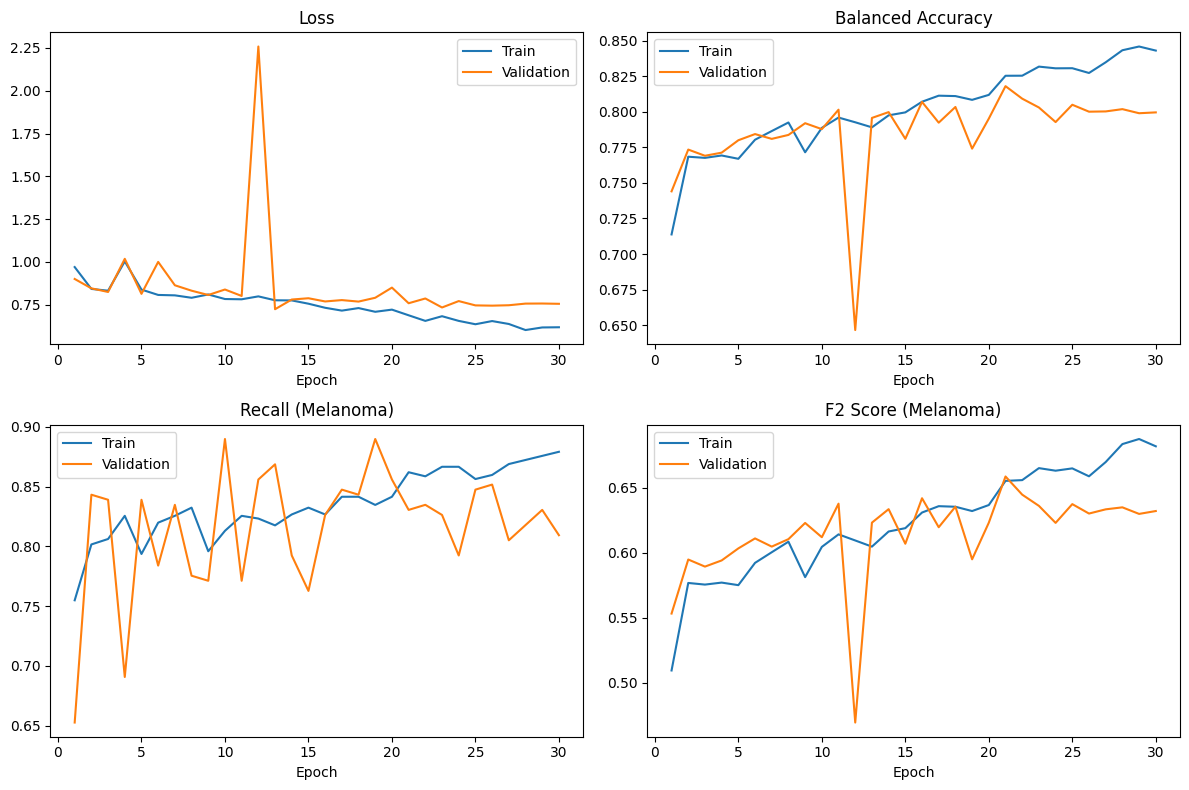

In [5]:
plot_training_curves(train_history, val_history)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet50_layer4_l1_metadata_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device, use_metadata=True)

Best threshold: 0.65 | Val F2: 0.6575


Threshold:          0.65
AUC-ROC:            0.8848
Balanced Accuracy:  0.7807
F2 Score:           0.6048

              precision    recall  f1-score   support

Non-Melanoma     0.9576    0.8597    0.9060      1340
    Melanoma     0.3896    0.7018    0.5010       171

    accuracy                         0.8418      1511
   macro avg     0.6736    0.7807    0.7035      1511
weighted avg     0.8933    0.8418    0.8602      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


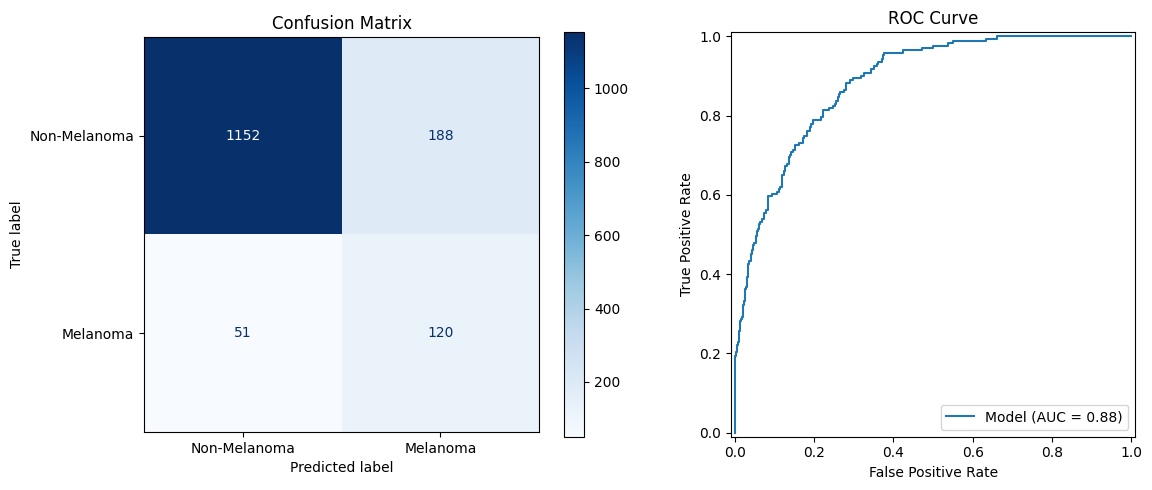

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold, use_metadata=True)